# Melbourne Housing & Crime Explorer

Interactive choropleth maps powered by **Folium** and **GeoPandas**.

| Map | Data | Granularity |
|-----|------|-------------|
| **CRIME** | Crime score (−3 most dangerous → +3 safest) | LGA |
| **HOUSE** | Median house price | Suburb |
| **UNITS** | Median unit price | Suburb |
| **RENT** | Weekly rent by type & bedrooms | Suburb |

> **First run:** postcode and LGA boundary files are downloaded from ABS and cached locally
> Delete cache files to force a fresh download/extraction.


This notebook will save files to html.

To view the files run 
```bash
python -m http.server 8080
```
from command line in same directory as melbourne_maps.ipynb then goto brower and type localhost:8080 to view the map files to view.

In [578]:
# Install required packages for the project
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('folium', 'geopandas', 'requests', 'branca', 'matplotlib', 'pyrosm')
print('All packages ready')

All packages ready



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [579]:
# Import libraries
import json, os, math, warnings
import requests
import pandas as pd
import geopandas as gpd
import folium
import branca.colormap as cm
from IPython.display import display
import ipywidgets as widgets
from pyrosm import OSM
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings and set display options
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
print('Imports complete')

Imports complete


In [580]:
# Read open data to dataframe
DATA_PATH = 'melbourne_housing_crime_data.json'
# PBF_PATH  = 'greater_melbourne.pbf'

OUTPUT_PATH = '../frontend/map_visualisations'
GEOJSON_PATH = 'geojson_files'

# create folder verification_visualisation if it doesn't exist
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

if not os.path.exists(GEOJSON_PATH):
    os.makedirs(GEOJSON_PATH)

with open(DATA_PATH, 'r') as f:
    raw = json.load(f)

records = []
for suburb, info in raw.items():
    rent   = info.get('rent') or {}
    weekly = rent.get('weeklyRent') or {}
    hp     = info.get('housePrices') or {}
    cl     = info.get('crimeLga') or {}
    rentScore = rent.get('rentScore') or {}

    records.append({
        'suburb'           : suburb,
        'postcode'         : info.get('postcode'),
        'lga'              : info.get('lga'),
        'bcarrRing'          : info.get('bcarrRing'),
        'crimeRate'        : cl.get('ratePer100k'),
        'crimeScore'       : cl.get('crimeScore'),
        'medianHousePrice' : hp.get('meanMedianHousePrice'),
        'medianUnitPrice'  : hp.get('meanMedianUnitPrice'),
        'housePriceScore' : hp.get('housePriceScore'),
        'unitPriceScore'  : hp.get('unitPriceScore'),
        'rent_1brFlat'     : weekly.get('1brFlat'),
        'rent_2brFlat'     : weekly.get('2brFlat'),
        'rent_3brFlat'     : weekly.get('3brFlat'),
        'rent_2brHouse'    : weekly.get('2brHouse'),
        'rent_3brHouse'    : weekly.get('3brHouse'),
        'rent_4brHouse'    : weekly.get('4brHouse'),
        'rent_all'         : weekly.get('all'),
        'rentScore_1brFlat'  : rentScore.get('1brFlat'),
        'rentScore_2brFlat'  : rentScore.get('2brFlat'),
        'rentScore_3brFlat'  : rentScore.get('3brFlat'),
        'rentScore_2brHouse' : rentScore.get('2brHouse'),
        'rentScore_3brHouse' : rentScore.get('3brHouse'),
        'rentScore_4brHouse' : rentScore.get('4brHouse'),
        'rentScore_all'      : rentScore.get('all'),
        'rentScoreAverage'   : rent.get('rentScoreAverage'),
    })

df = pd.DataFrame(records)
print(f'Loaded {len(df)} suburbs across {df["lga"].nunique()} LGAs')

Loaded 544 suburbs across 31 LGAs


In [581]:
melbourne_lgas = df['lga'].unique()
print(melbourne_lgas)

['Melbourne' 'Yarra' 'Moonee Valley' 'Port Phillip' 'Stonnington'
 'Glen Eira' 'Darebin' 'Banyule' 'Whittlesea' 'Nillumbik' 'Merri-bek'
 'Hume' 'Melton' 'Brimbank' 'Boroondara' 'Whitehorse' 'Knox'
 'Yarra Ranges' 'Manningham' 'Maroondah' 'Monash' 'Cardinia' 'Bayside'
 'Kingston' 'Casey' 'Greater Dandenong' 'Mornington Peninsula' 'Frankston'
 'Hobsons Bay' 'Wyndham' 'Maribyrnong']


In [582]:
# ── Helpers ──────────────────────────────────────────────────────────────────
def fetch_geojson(url, cache_path, label=''):
    if os.path.exists(cache_path):
        print(f'  Using cached {label}: {cache_path}')
        return gpd.read_file(cache_path)
    print(f'  Downloading {label} ...', end=' ', flush=True)
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(cache_path, 'wb') as f:
        f.write(r.content)
    print(f'done ({len(r.content)//1024} KB)')
    return gpd.read_file(cache_path)

def fetch_geojson_paginated(url_base, cache_path, label='', page_size=1000):
    cache_path = os.path.join(GEOJSON_PATH, cache_path)
    if os.path.exists(cache_path):
        print(f'  Using cached {label}: {cache_path}')
        return gpd.read_file(cache_path)
    
    print(f'  Downloading {label} (paginated) ...', flush=True)
    all_features = []
    offset = 0

    while True:
        url = f"{url_base}&resultOffset={offset}&resultRecordCount={page_size}"
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        data = r.json()
        features = data.get('features', [])
        all_features.extend(features)
        print(f'    fetched {len(all_features)} so far...')
        if len(features) < page_size:
            break
        offset += page_size

    geojson = {'type': 'FeatureCollection', 'features': all_features}
    with open(cache_path, 'w') as f:
        json.dump(geojson, f)
    print(f'  done ({len(all_features)} features)')
    return gpd.read_file(cache_path)

def try_fetch(urls_and_paths):
    for url, cache_path, label in urls_and_paths:
        cache_path = os.path.join(GEOJSON_PATH, cache_path)
        try:
            return fetch_geojson(url, cache_path, label)
        except Exception as e:
            print(f'  WARNING: {label} failed: {e}')
    raise RuntimeError('All geo sources failed - check your internet connection.')

# def fetch_osm_pbf(pbf_path, cache_path='vic_suburbs_osm.geojson'):
#     if os.path.exists(cache_path):
#         print(f'  Using cached OSM suburbs: {cache_path}')
#         return gpd.read_file(cache_path)
#     print('  Extracting suburb boundaries from PBF ...', flush=True)
#     osm = OSM(pbf_path)
#     boundaries = osm.get_boundaries()
#     suburbs = boundaries[boundaries['admin_level'] == '9'].copy()
#     suburbs = suburbs[['name', 'geometry']].rename(columns={'name': 'suburb_name'})
#     suburbs = suburbs[suburbs.geometry.notna()].copy()
#     suburbs.to_file(cache_path, driver='GeoJSON')
#     print(f'  done ({len(suburbs)} suburbs)')
#     return suburbs

# ── Download / load boundaries ────────────────────────────────────────────────
print('Fetching postcode boundaries (gap-fill) ...')
gdf_postcode = try_fetch([
    (
        'https://geo.abs.gov.au/arcgis/rest/services/ASGS2021/POA/MapServer/0/query'
        '?where=POA_CODE_2021+LIKE+\'3%25\'&outFields=POA_CODE_2021'
        '&returnGeometry=true&f=geojson',
        'vic_postcodes.geojson', 'ABS Postcode VIC'
    ),
])

print('Fetching LGA boundaries ...')
gdf_lga = try_fetch([
    (
        'https://geo.abs.gov.au/arcgis/rest/services/ASGS2021/LGA/MapServer/0/query'
        '?where=STATE_CODE_2021%3D\'2\'&outFields=LGA_NAME_2021,LGA_CODE_2021'
        '&returnGeometry=true&f=geojson',
        'vic_lgas.geojson', 'ABS LGA VIC'
    ),
])

# print('Loading suburb boundaries from PBF ...')
# gdf_suburb_osm = fetch_osm_pbf(PBF_PATH)

gdf_suburb = fetch_geojson_paginated(
    'https://geo.abs.gov.au/arcgis/rest/services/ASGS2021/SAL/MapServer/0/query'
    '?where=STATE_CODE_2021%3D%272%27&outFields=SAL_NAME_2021,SAL_CODE_2021'
    '&returnGeometry=true&f=geojson',
    'vic_suburbs.geojson', 'ABS SAL VIC'
)

gdf_lga = gdf_lga.rename(columns={'lga_name_2021': 'lga_name'})
gdf_lga['lga_name'] = gdf_lga['lga_name'].str.replace(r'\s*\(Vic\.\)$', '', regex=True)

gdf_suburb = gdf_suburb.rename(columns={'sal_name_2021': 'suburb_name'})

def clean_suburb_name(name, melbourne_lgas=melbourne_lgas):
    # Has "(LGA - Vic.)" pattern — only keep if LGA is a Melbourne one
    m = re.match(r'^(.*?)\s*\(([^)]+?)\s*-\s*Vic\.\)$', name)
    if m:
        suburb, lga = m.group(1), m.group(2)
        suburb_output = suburb if lga in melbourne_lgas else None  # drop non-Melbourne duplicates
        if suburb_output:
            print('  matched LGA pattern:', suburb_output)
        return suburb_output
    
    # Has plain "(Vic.)" suffix — strip it and keep
    name = re.sub(r'\s*\(Vic\.\)$', '', name)
    return name

gdf_suburb['suburb_name'] = gdf_suburb['suburb_name'].apply(clean_suburb_name)
gdf_suburb = gdf_suburb[gdf_suburb['suburb_name'].notna()].copy()

print('Boundaries loaded')
print(f'  Suburb geo  : {len(gdf_suburb)} features')
print(f'  Postcode geo: {len(gdf_postcode)} features')
print(f'  LGA geo     : {len(gdf_lga)} features')

Fetching postcode boundaries (gap-fill) ...
  Using cached ABS Postcode VIC: geojson_files/vic_postcodes.geojson
Fetching LGA boundaries ...
  Using cached ABS LGA VIC: geojson_files/vic_lgas.geojson
  Using cached ABS SAL VIC: geojson_files/vic_suburbs.geojson
  matched LGA pattern: Bellfield
  matched LGA pattern: Hillside
Boundaries loaded
  Suburb geo  : 2918 features
  Postcode geo: 694 features
  LGA geo     : 82 features


In [583]:
print(gdf_lga.columns)
print(sorted(gdf_lga['lga_name'].unique()))
print(gdf_suburb.columns)
print(sorted(gdf_suburb['suburb_name'].unique()))

Index(['lga_name', 'lga_code_2021', 'shape', 'geometry'], dtype='object')
['Alpine', 'Ararat', 'Ballarat', 'Banyule', 'Bass Coast', 'Baw Baw', 'Bayside', 'Benalla', 'Boroondara', 'Brimbank', 'Buloke', 'Campaspe', 'Cardinia', 'Casey', 'Central Goldfields', 'Colac Otway', 'Corangamite', 'Darebin', 'East Gippsland', 'Frankston', 'Gannawarra', 'Glen Eira', 'Glenelg', 'Golden Plains', 'Greater Bendigo', 'Greater Dandenong', 'Greater Geelong', 'Greater Shepparton', 'Hepburn', 'Hindmarsh', 'Hobsons Bay', 'Horsham', 'Hume', 'Indigo', 'Kingston', 'Knox', 'Latrobe', 'Loddon', 'Macedon Ranges', 'Manningham', 'Mansfield', 'Maribyrnong', 'Maroondah', 'Melbourne', 'Melton', 'Migratory - Offshore - Shipping', 'Mildura', 'Mitchell', 'Moira', 'Monash', 'Moonee Valley', 'Moorabool', 'Moreland', 'Mornington Peninsula', 'Mount Alexander', 'Moyne', 'Murrindindi', 'Nillumbik', 'No usual address', 'Northern Grampians', 'Port Phillip', 'Pyrenees', 'Queenscliffe', 'South Gippsland', 'Southern Grampians', 'Ston

In [584]:
# ── Harmonise column names & build match keys ────────────────────────────────
def detect_name_col(gdf, candidates):
    cols_lower = {c.lower(): c for c in gdf.columns}
    for c in candidates:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    raise KeyError(f'None of {candidates} found in {list(gdf.columns)}')

# suburb_name already set by fetch_osm_pbf; only rename if missing
if 'suburb_name' not in gdf_suburb.columns:
    col = detect_name_col(gdf_suburb, [
        'LOC_NAME', 'SAL_NAME_2022', 'SAL_NAME_2021', 'SAL_NAME21',
        'locality_name', 'name', 'SUBURB_NAME', 'Name'
    ])
    gdf_suburb = gdf_suburb.rename(columns={col: 'suburb_name'})

lga_name_col = detect_name_col(gdf_lga, [
    'LGA_NAME_2021', 'LGA_NAME21', 'lga_name', 'name', 'Name', 'LGA_NAME'
])
gdf_lga = gdf_lga.rename(columns={lga_name_col: 'lga_name'})

print(gdf_suburb.columns)
print(gdf_suburb['suburb_name'].unique())


# Upper-case keys; strip ABS state suffixes e.g. '(VIC.)'
gdf_suburb['suburb_key'] = (gdf_suburb['suburb_name'].str.strip().str.upper()
                             .str.replace(r'\s*\([^)]+\)$', '', regex=True).str.strip())
gdf_lga['lga_key']       = (gdf_lga['lga_name'].str.strip().str.upper()
                             .str.replace(r'\s*\([^)]+\)$', '', regex=True).str.strip())

# Fix renamed councils
gdf_lga['lga_key'] = gdf_lga['lga_key'].replace({'MORELAND': 'MERRI-BEK'})

df['suburb_key'] = df['suburb'].str.strip().str.upper()
df['lga_key']    = df['lga'].str.strip().str.upper()

# Add boolean flag columns showing if lga is present in melbourne_housing_crime_data.json (1 for true, 0 for false)
gdf_lga['lga_in_data']    = gdf_lga['lga_key'].isin(df['lga_key']).astype(int)
gdf_suburb['suburb_in_data'] = gdf_suburb['suburb_key'].isin(df['suburb_key']).astype(int)

# # Add boolean flag columns showing if lga/suburb has crime data (non-null crimeScore). Lookup from df using lga_key/suburb_key to ensure we are checking the correct rows, rather than relying on order of gdf vs df
# gdf_lga['lga_has_crime_data']    = gdf_lga['lga_key'].map(df.set_index('lga_key')['crimeScore'].notna()).fillna(False)
# gdf_suburb['suburb_has_crime_data'] = gdf_suburb['suburb_key'].map(df.set_index('suburb_key')['crimeScore'].notna()).fillna(False)

# # Add boolean flag columns showing if lga/suburb has house price data (non-null medianHousePrice)
# gdf_lga['lga_has_price_data']    = gdf_lga['lga_key'].map(df.set_index('lga_key')['medianHousePrice'].notna()).fillna(False)
# gdf_suburb['suburb_has_price_data'] = gdf_suburb['suburb_key'].map(df.set_index('suburb_key')['medianHousePrice'].notna()).fillna(False)

# # Add boolean flag columns showing if lga/suburb has rent data (non-null rent_all)
# gdf_lga['lga_has_rent_data']    = gdf_lga['lga_key'].map(df.set_index('lga_key')['rent_all'].notna()).fillna(False)
# gdf_suburb['suburb_has_rent_data'] = gdf_suburb['suburb_key'].map(df.set_index('suburb_key')['rent_all'].notna()).fillna(False)

metro_lga_keys   = set(df['lga_key'].dropna().unique())
metro_sub_keys   = set(df['suburb_key'].dropna().unique())
gdf_lga_metro    = gdf_lga[gdf_lga['lga_key'].isin(metro_lga_keys)].copy()
gdf_lga_metro['geometry'] = gdf_lga_metro['geometry'].simplify(
    tolerance=0.0001, preserve_topology=True
)

gdf_suburb_metro = gdf_suburb[gdf_suburb['suburb_key'].isin(metro_sub_keys)].copy()
gdf_suburb_metro['geometry'] = gdf_suburb_metro['geometry'].simplify(
    tolerance=0.0001, preserve_topology=True
)

print(f'Metro LGAs matched    : {len(gdf_lga_metro)} / {df["lga"].nunique()}')
print(f'Metro suburbs matched : {len(gdf_suburb_metro)} / {len(df)}')


Index(['suburb_name', 'sal_code_2021', 'shape', 'geometry'], dtype='object')
['Abbeyard' 'Abbotsford' 'Aberfeldie' ... 'Zumsteins' 'No usual address'
 'Migratory - Offshore - Shipping']
Metro LGAs matched    : 31 / 31
Metro suburbs matched : 543 / 544


In [585]:
# def print_pairs(df, col1, col2, count=5):
#     """
#     Print pairs of values from two columns in a DataFrame in rows of 5, starting from a given index. If there are 20 pairs, it will print 4 rows of 5 pairs each.
#         - df: DataFrame containing the columns
#         - col1: Name of the first column (e.g., 'lga_name')
#         - col2: Name of the second column (e.g., 'lga_key')
#         - count: Number of pairs to print per row (default is 5)
#     """
#     for i in range(0, len(df)//count):
#         names = df[col1].iloc[i*count:(i+1)*count].tolist()
#         keys  = df[col2].iloc[i*count:(i+1)*count].tolist()
#         pairs = [f'{n} -> {k}' for n, k in zip(names, keys)]
#         print(pairs)

# print(gdf_lga.columns)

# gdf_lga = gdf_lga.sort_values('lga_name').reset_index(drop=True)
# gdf_lga_matched = gdf_lga[gdf_lga['lga_name'].str.upper() == gdf_lga['lga_key']].copy()
# gdf_lga_unmatched = gdf_lga[gdf_lga['lga_name'].str.upper() != gdf_lga['lga_key']].copy()

# print(f'Matched LGAs: {len(gdf_lga_matched)}')
# print_pairs(gdf_lga_matched, 'lga_name', 'lga_key', 5)

# print(f'Unmatched LGAs: {len(gdf_lga_unmatched)}')
# print_pairs(gdf_lga_unmatched, 'lga_name', 'lga_key', 5)

In [586]:
# print(gdf_suburb.columns)

# gdf_suburb = gdf_suburb.sort_values('suburb_name').reset_index(drop=True)
# gdf_suburb_matched = gdf_suburb[gdf_suburb['suburb_name'].str.upper() == gdf_suburb['suburb_key']].copy()
# gdf_suburb_unmatched = gdf_suburb[gdf_suburb['suburb_name'].str.upper() != gdf_suburb['suburb_key']].copy()

# print(f'Matched Suburbs: {len(gdf_suburb_matched)}')
# print_pairs(gdf_suburb_matched, 'suburb_name', 'suburb_key', 5)

# print(f'Unmatched Suburbs: {len(gdf_suburb_unmatched)}')
# print_pairs(gdf_suburb_unmatched, 'suburb_name', 'suburb_key', 5)

In [587]:
# ── Aggregate crime to LGA & merge suburb prices ──────────────────────────────
df_lga_crime = (
    df.dropna(subset=['crimeScore'])
      .groupby('lga_key', as_index=False)
      .agg(lga=('lga', 'first'),
           crimeRate=('crimeRate', 'first'),
           crimeScore=('crimeScore', 'first'))
)

print(gdf_suburb_metro.columns.tolist())
print(gdf_suburb_metro[gdf_suburb_metro['suburb_key'].isin(['MALVERN', 'PRAHRAN'])])

print(sorted(df['suburb_key'].unique()))
print(sorted(metro_sub_keys))
print(sorted(gdf_suburb_metro['suburb_key'].unique()))


gdf_crime = gdf_lga_metro.merge(df_lga_crime, on='lga_key', how='left')
print(f'LGAs with crime data: {gdf_crime["crimeScore"].notna().sum()} / {len(gdf_crime)}')

gdf_prices = gdf_suburb_metro.merge(
    df[['suburb_key', 'suburb', 'lga', 'bcarrRing',
        'medianHousePrice', 'medianUnitPrice',
        'rent_1brFlat', 'rent_2brFlat', 'rent_3brFlat',
        'rent_2brHouse', 'rent_3brHouse', 'rent_4brHouse', 
        'rent_all',
        'housePriceScore', 'unitPriceScore', 
        'rentScore_1brFlat', 'rentScore_2brFlat', 'rentScore_3brFlat', 
        'rentScore_2brHouse', 'rentScore_3brHouse', 'rentScore_4brHouse', 
        'rentScore_all','rentScoreAverage']],
    on='suburb_key', how='left'
)
gdf_prices['in_dataset'] = gdf_prices['suburb'].notna()

# print(f'Suburbs with house price data : {gdf_prices["medianHousePrice"].notna().sum()}')
# print(f'Suburbs with unit price data  : {gdf_prices["medianUnitPrice"].notna().sum()}')
# print(f'Suburbs with rent data        : {gdf_prices["rent_all"].notna().sum()}')
# print(gdf_prices[gdf_prices['suburb'] == 'Melbourne'])


['suburb_name', 'sal_code_2021', 'shape', 'geometry', 'suburb_key', 'suburb_in_data']
     suburb_name sal_code_2021 shape  \
1585     Malvern         21586  None   
2117     Prahran         22118  None   

                                               geometry suburb_key  \
1585  POLYGON ((145.02998 -37.8479, 145.02973 -37.84...    MALVERN   
2117  POLYGON ((145.00244 -37.85309, 145.00137 -37.8...    PRAHRAN   

      suburb_in_data  
1585               1  
2117               1  
['ABBOTSFORD', 'ABERFELDIE', 'AINTREE', 'AIRPORT WEST', 'ALBANVALE', 'ALBERT PARK', 'ALBION', 'ALPHINGTON', 'ALTONA', 'ALTONA MEADOWS', 'ALTONA NORTH', 'ARDEER', 'ARMADALE', 'ARTHURS CREEK', 'ARTHURS SEAT', 'ASCOT VALE', 'ASHBURTON', 'ASHWOOD', 'ASPENDALE', 'ASPENDALE GARDENS', 'ATTWOOD', 'AVONDALE HEIGHTS', 'AVONSLEIGH', 'BADGER CREEK', 'BALACLAVA', 'BALNARRING', 'BALNARRING BEACH', 'BALWYN', 'BALWYN NORTH', 'BANGHOLME', 'BAXTER', 'BAYLES', 'BAYSWATER', 'BAYSWATER NORTH', 'BEACONSFIELD', 'BEACONSFIELD UPPER

In [588]:
# ── Choropleth helper ─────────────────────────────────────────────────────────
# MELBOURNE_CENTRE = [-37.84, 144.95]
MELBOURNE_CENTRE = [-37.9, 145.15]
ZOOM_START       = 10

PALETTES = {
    'crime': ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641'],  # red->green
    'crime_colourblind': ['#d73027', '#fc8d59', '#ffffbf', '#91bfdb', '#4575b4'],  # orange->blue
    'house': ['#ffffcc', '#c7e9b4', '#41b6c4', '#2c7fb8', '#253494'],  # light->dark blue
    # house colourblind blue->orange
    'house_colourblind': ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],  # light->dark orange (same as 'house' but more distinct for colourblind)
    # 'house_colourblind': ['#ffffcc', '#a1dab4', '#41b6c4', '#2c7fb8', '#253494'],  # light->dark blue (same as 'house' but more distinct for colourblind)
    'unit' : ['#fff7fb', '#ece2f0', '#a6bddb', '#2b8cbe', '#014636'],  # light->teal
    'rent' : ['#f7fcf0', '#ccebc5', '#7bccc4', '#2b8cbe', '#08306b'],  # light->dark
    'boolean': ['#cccccc','#6699cc'],  # blue for True, grey for False
}

NULL_COLOUR = '#888888'

def fmt_currency(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'N/A'
    if v >= 1_000_000:
        return f'${v/1_000_000:.2f}M'
    if v >= 1_000:
        return f'${v/1_000:.0f}K'
    return f'${v:.0f}'

def fmt_rate(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'N/A'
    return f'{v:,.0f}'

def fmt_score(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'N/A'
    return f'{v:+.2f}'

def fmt_crime(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'N/A'
    return f'{v:,.0f} per 100k'

def build_choropleth(gdf, name_col, title,
                     value_col=None, palette_key='blue',
                     legend_name='', fmt_fn=fmt_currency,
                     extra_tooltip_cols=None, null_color=NULL_COLOUR):

    has_values = value_col is not None

    extra_cols = [col for col, _ in (extra_tooltip_cols or [])]
    if 'in_dataset' in gdf.columns:
        extra_cols = ['in_dataset'] + extra_cols

    cols = [name_col, 'geometry'] + extra_cols
    if has_values:
        cols.insert(1, value_col)
    sub = gdf[cols].copy()
    sub = sub[sub.geometry.notna()].copy()

    if has_values:
        sub_valid = sub.dropna(subset=[value_col])
        vmin = sub_valid[value_col].min()
        vmax = sub_valid[value_col].max()
        colormap = cm.LinearColormap(
            colors=PALETTES[palette_key], vmin=vmin, vmax=vmax, caption=legend_name
        )
    else:
        colormap = None

    def style_fn(feature):
        in_ds = feature['properties'].get('in_dataset', False)
        if not has_values:
            return {'fillColor': null_color, 'color': '#444', 'weight': 0.8, 'fillOpacity': 0.75}
        val = feature['properties'].get(value_col)
        if val is None and not in_ds:
            return {'fillColor': '#888888', 'color': '#666', 'weight': 0.5, 'fillOpacity': 0.3}
        if val is None:
            return {'fillColor': null_color, 'color': '#888', 'weight': 0.8, 'fillOpacity': 0.6}
        return {'fillColor': colormap(val), 'color': '#444', 'weight': 0.8, 'fillOpacity': 0.75}

    def highlight_fn(feature):
        return {'weight': 2.5, 'color': '#222', 'fillOpacity': 0.9}

    m = folium.Map(location=MELBOURNE_CENTRE, zoom_start=ZOOM_START,
                   tiles='CartoDB positron', prefer_canvas=True)

    if has_values:
        sub['__fmt'] = sub[value_col].apply(lambda x: fmt_fn(x) if pd.notna(x) else 'No data')
        tooltip_fields  = [name_col, '__fmt']
        tooltip_aliases = ['Name:', legend_name + ':']
    else:
        tooltip_fields  = [name_col]
        tooltip_aliases = ['Name:']

    if extra_tooltip_cols:
        for col, lbl in extra_tooltip_cols:
            sub[f'__fmt_{col}'] = sub[col].apply(
                lambda x: fmt_rate(x) if pd.notna(x) else 'No data'
            )
            tooltip_fields.append(f'__fmt_{col}')
            tooltip_aliases.append(lbl)

    folium.GeoJson(
        sub.__geo_interface__,
        style_function=style_fn,
        highlight_function=highlight_fn,
        tooltip=folium.GeoJsonTooltip(
            fields=tooltip_fields, aliases=tooltip_aliases,
            localize=True, sticky=True, style='font-size:13px; padding:6px;'
        ),
    ).add_to(m)

    if colormap:
        colormap.add_to(m)

    title_html = (
        '<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);'
        'background:white;padding:8px 18px;border-radius:8px;'
        'box-shadow:0 2px 8px rgba(0,0,0,.25);font-family:sans-serif;'
        'font-size:15px;font-weight:600;z-index:9999;white-space:nowrap;">'
        f'{title}</div>'
    )
    m.get_root().html.add_child(folium.Element(title_html))
    # m.fit_bounds(m.get_bounds(), padding=(30, 30))
    return m

print('Helper functions defined')


Helper functions defined


In [589]:
# ── Data summary ──────────────────────────────────────────────────────────────
print('=' * 55)
print('  Melbourne Metro - Data Summary')
print('=' * 55)
print(f'\n{"Suburbs in dataset":<35} {len(df):>6}')
print(f'{"LGAs in dataset":<35} {df["lga"].nunique():>6}')
print(f'{"Suburbs with house price data":<35} {df["medianHousePrice"].notna().sum():>6}')
print(f'{"Suburbs with unit price data":<35} {df["medianUnitPrice"].notna().sum():>6}')
print(f'{"Suburbs with rent data":<35} {df["rent_all"].notna().sum():>6}')

print('\n-- Crime Score (LGA, lowest to highest) ----------')
for _, row in df_lga_crime.sort_values('crimeScore').head(5).iterrows():
    print(f'  {row["lga"]:<28} {row["crimeScore"]:>+7.2f}')
print('  ...')
for _, row in df_lga_crime.sort_values('crimeScore').tail(3).iterrows():
    print(f'  {row["lga"]:<28} {row["crimeScore"]:>+7.2f}')

print('\n-- Median House Price (top 5 suburbs) -------------')
for _, row in df.nlargest(5, 'medianHousePrice')[['suburb','medianHousePrice']].iterrows():
    print(f'  {row["suburb"]:<28} {fmt_currency(row["medianHousePrice"])}')


  Melbourne Metro - Data Summary

Suburbs in dataset                     544
LGAs in dataset                         31
Suburbs with house price data          412
Suburbs with unit price data           303
Suburbs with rent data                 166

-- Crime Score (LGA, lowest to highest) ----------
  Darebin                        -3.00
  Frankston                      -3.00
  Maribyrnong                    -3.00
  Greater Dandenong              -3.00
  Port Phillip                   -3.00
  ...
  Yarra Ranges                   +2.30
  Manningham                     +3.00
  Nillumbik                      +3.00

-- Median House Price (top 5 suburbs) -------------
  Toorak                       $5.49M
  Canterbury                   $3.55M
  Brighton                     $3.50M
  Portsea                      $3.41M
  Deepdene                     $3.36M


# Local Government Areas

In [590]:
# Local Government Areas choropleth, coloured by whether they have crime data or not (1 for yes, 0 for no)
m_lga = build_choropleth(
    gdf        = gdf_lga,
    value_col  = 'lga_in_data',  # colour by whether LGA has crime data or not
    name_col   = 'lga_key',
    palette_key= 'boolean',
    title      = 'Local Government Areas',
    legend_name= 'LGA',
    fmt_fn     = lambda v: f'{v:+.2f}' if pd.notna(v) else 'No data',
    # extra_tooltip_cols=[('crimeRate', 'Crime Rate (per 100k):')],
)
m_lga.save(OUTPUT_PATH+'/a_map_lga.html')
# display(m_lga)

# Suburbs

In [591]:
# Suburbs choropleth, coloured by whether they are included as shape files
m_suburb = build_choropleth(
    gdf        = gdf_suburb,
    value_col  = 'suburb_in_data',  # colour by whether suburb has crime data or not
    name_col   = 'suburb_name',
    palette_key= 'boolean',
    title      = 'Suburbs',
    legend_name= 'Suburb',
    fmt_fn     = lambda v: f'{v:+.2f}' if pd.notna(v) else 'No data',
)
m_suburb.save(OUTPUT_PATH+'/b_map_suburb.html')
# display(m_suburb)

# Crime Rate by Local Goverment Area

In [592]:
# ── CRIME – Crime score by LGA ────────────────────────────────────────────────
m_crime = build_choropleth(
    gdf        = gdf_crime,
    value_col  = 'crimeScore',
    name_col   = 'lga_name',
    palette_key= 'crime_colourblind',
    title      = 'Crime Z-Score (relative to median) by LGA  (-3 = most dangerous, +3 = safest)',
    legend_name= 'Crime Z-Score',
    fmt_fn     = lambda v: f'{v:+.2f}' if pd.notna(v) else 'No data',
    extra_tooltip_cols=[('crimeRate', 'Crime Rate (per 100k):')],
)
m_crime.save(OUTPUT_PATH+'/c_map_crime.html')
# display(m_crime)


# Median House Price and Z-Score by Suburb

In [593]:
# ── HOUSE – Median house price by suburb ──────────────────────────────────────
m_house = build_choropleth(
    gdf        = gdf_prices,
    value_col  = 'housePriceScore',  # colour by unit price score (relative to metro median), which is more complete than house price data
    name_col   = 'suburb',
    palette_key= 'house_colourblind',
    title      = 'Median House Price & Z-Score (relative to median) - by Suburb',
    legend_name= 'House Price Z-Score',
    fmt_fn     = fmt_score,
    extra_tooltip_cols=[('medianHousePrice', 'Median House Price:')],
)
m_house.save(OUTPUT_PATH+'/d_map_house.html')
# display(m_house)

# Median Unit Price and Z-Score by Suburb

In [594]:
# ── HOUSE – Median house price by suburb ──────────────────────────────────────
m_unit = build_choropleth(
    gdf        = gdf_prices,
    value_col  = 'unitPriceScore',  # colour by unit price score (relative to metro median), which is more complete than house price data
    name_col   = 'suburb',
    palette_key= 'house_colourblind',
    title      = 'Median Unit Price & Z-Score (relative to median) - by Suburb',
    legend_name= 'Unit Price Z-Score',
    fmt_fn     = fmt_score,
    extra_tooltip_cols=[('medianUnitPrice', 'Median Unit Price:')],
)
m_unit.save(OUTPUT_PATH+'/e_map_unit.html')
# display(m_unit)

# Rent Prices and Z-Score by House/Unit/Bedrooms with Average

In [595]:
# ── BCARR – City ring classification by suburb ────────────────────────────────
# Colours suburbs by their BCARR ring: Inner, Middle, or Outer.
# Suburbs with no ring data (bcarrRing is null) are shown in grey.

RING_COLOURS = {
    'Inner':  '#c51b7d',   # magenta
    'Middle': '#4d9221',   # green
    'Outer':  '#2166ac',   # blue
}

def ring_style_fn(feature):
    ring = feature['properties'].get('bcarrRing')
    if ring in RING_COLOURS:
        return {'fillColor': RING_COLOURS[ring], 'color': '#444', 'weight': 0.8, 'fillOpacity': 0.7}
    return {'fillColor': '#aaaaaa', 'color': '#888', 'weight': 0.5, 'fillOpacity': 0.3}

def ring_highlight_fn(feature):
    return {'weight': 2.5, 'color': '#222', 'fillOpacity': 0.9}

m_ring = folium.Map(location=MELBOURNE_CENTRE, zoom_start=ZOOM_START,
                    tiles='CartoDB positron', prefer_canvas=True)

gdf_ring = gdf_prices[['suburb', 'bcarrRing', 'lga', 'geometry']].copy()
gdf_ring = gdf_ring[gdf_ring.geometry.notna()].copy()

folium.GeoJson(
    gdf_ring.__geo_interface__,
    style_function=ring_style_fn,
    highlight_function=ring_highlight_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=['suburb', 'bcarrRing', 'lga'],
        aliases=['Suburb:', 'Ring:', 'LGA:'],
        localize=True, sticky=True, style='font-size:13px; padding:6px;'
    ),
).add_to(m_ring)

# Legend
legend_html = (
    '<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
    'padding:10px 16px;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,.25);'
    'font-family:sans-serif;font-size:13px;">'
    '<b>BCARR Ring</b><br>'
    + ''.join(
        f'<span style="display:inline-block;width:14px;height:14px;border-radius:3px;'
        f'background:{col};margin-right:6px;vertical-align:middle;"></span>{ring}<br>'
        for ring, col in RING_COLOURS.items()
    )
    + '<span style="display:inline-block;width:14px;height:14px;border-radius:3px;'
    'background:#aaaaaa;margin-right:6px;vertical-align:middle;"></span>No data'
    '</div>'
)
m_ring.get_root().html.add_child(folium.Element(legend_html))

title_html = (
    '<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);'
    'background:white;padding:8px 18px;border-radius:8px;'
    'box-shadow:0 2px 8px rgba(0,0,0,.25);font-family:sans-serif;'
    'font-size:15px;font-weight:600;z-index:9999;white-space:nowrap;">'
    'BCARR City Ring Classification — Melbourne Suburbs</div>'
)
m_ring.get_root().html.add_child(folium.Element(title_html))

# m_ring.fit_bounds(m_ring.get_bounds(), padding=(30, 30))
m_ring.save(OUTPUT_PATH + '/h_melbourne_suburbs_by_ring.html')
print('Saved: melbourne_suburbs_by_ring.html')

Saved: melbourne_suburbs_by_ring.html


# Rent Prices and Z-Score by House/Unit/Bedrooms with Average

Average calculated by averaging Z-scores excluding 1 bedroom flats which dont correlate well with other rents



In [596]:
# ── RENT – Save all combinations as separate HTML files ───────────────────────
RENT_COLS = {
    ('House', '2 BR'): 'rent_2brHouse',
    ('House', '3 BR'): 'rent_3brHouse',
    ('House', '4 BR'): 'rent_4brHouse',
    ('Unit',  '1 BR'): 'rent_1brFlat',
    ('Unit',  '2 BR'): 'rent_2brFlat',
    ('Unit',  '3 BR'): 'rent_3brFlat',
}

RENT_SCORE_COLS = {
    ('House', '2 BR'): 'rentScore_2brHouse',
    ('House', '3 BR'): 'rentScore_3brHouse',
    ('House', '4 BR'): 'rentScore_4brHouse',
    ('Unit',  '1 BR'): 'rentScore_1brFlat',
    ('Unit',  '2 BR'): 'rentScore_2brFlat',
    ('Unit',  '3 BR'): 'rentScore_3brFlat',
}

for (prop_type, br), col in RENT_SCORE_COLS.items():
    col_1    = RENT_COLS[(prop_type, br)]
    filename = f"g_map_rentScore_{prop_type}_{br.replace(' ', '')}.html"
    m = build_choropleth(
        gdf        = gdf_prices,
        value_col  = col,
        name_col   = 'suburb',
        palette_key= 'house_colourblind',
        title      = f'Rent Score - {br} {prop_type} - by Suburb',
        legend_name= f'Rent Score ({br} {prop_type})',
        fmt_fn     = fmt_score,
        extra_tooltip_cols=[(col_1, 'Median Rent ($/wk):')],
        null_color = NULL_COLOUR,
    )
    m.save(OUTPUT_PATH + '/' + filename)
    print(f'Saved: {filename}')

# Score average
m_avg = build_choropleth(
    gdf        = gdf_prices,
    value_col  = 'rentScoreAverage',
    name_col   = 'suburb',
    palette_key= 'house_colourblind',
    title      = 'Rent Score Average (2–4 BR, excl. 1BR & all) - by Suburb',
    legend_name= 'Rent Score Average',
    fmt_fn     = fmt_score,
    null_color = NULL_COLOUR,
)
m_avg.save(OUTPUT_PATH + '/f_map_rentScoreAverage.html')
print('Saved: f_map_rentScoreAverage.html')

Saved: g_map_rentScore_House_2BR.html
Saved: g_map_rentScore_House_3BR.html
Saved: g_map_rentScore_House_4BR.html
Saved: g_map_rentScore_Unit_1BR.html
Saved: g_map_rentScore_Unit_2BR.html
Saved: g_map_rentScore_Unit_3BR.html
Saved: f_map_rentScoreAverage.html


## Interactive Map

Only use if you delete cell output before saving. If you push to GitHub it may get blocked (file too large)

Press "By Type" to toggle between Unit/House and Bedrooms. Press Average Score to get the Average above.

In [597]:
# ── RENT – Interactive property type & bedroom selector ───────────────────────
RENT_COLS = {
    ('House', '2 BR'): 'rent_2brHouse',
    ('House', '3 BR'): 'rent_3brHouse',
    ('House', '4 BR'): 'rent_4brHouse',
    ('Unit',  '1 BR'): 'rent_1brFlat',
    ('Unit',  '2 BR'): 'rent_2brFlat',
    ('Unit',  '3 BR'): 'rent_3brFlat',
}

RENT_SCORE_COLS = {
    ('House', '2 BR'): 'rentScore_2brHouse',
    ('House', '3 BR'): 'rentScore_3brHouse',
    ('House', '4 BR'): 'rentScore_4brHouse',
    ('Unit',  '1 BR'): 'rentScore_1brFlat',
    ('Unit',  '2 BR'): 'rentScore_2brFlat',
    ('Unit',  '3 BR'): 'rentScore_3brFlat',
}
BR_OPTIONS = {'House': ['2 BR', '3 BR', '4 BR'], 'Unit': ['1 BR', '2 BR', '3 BR']}

mode_w = widgets.ToggleButtons(
    options=['By Type', 'Score Average'], description='Mode:', button_style='success', value='By Type'
)
prop_type_w = widgets.ToggleButtons(
    options=['House', 'Unit'], description='Type:', button_style='info', value='House'
)
bedroom_w = widgets.ToggleButtons(
    options=BR_OPTIONS['House'], description='Bedrooms:', button_style='warning', value='3 BR'
)
output_w = widgets.Output()

def update_bedrooms(change):
    bedroom_w.options = BR_OPTIONS[change['new']]
    bedroom_w.value   = BR_OPTIONS[change['new']][0]

def update_mode(change):
    is_avg = change['new'] == 'Score Average'
    prop_type_w.disabled = is_avg
    bedroom_w.disabled   = is_avg
    render_rent_map()

def render_rent_map(*args):
    if mode_w.value == 'Score Average':
        m = build_choropleth(
            gdf        = gdf_prices,
            value_col  = 'rentScoreAverage',
            name_col   = 'suburb',
            palette_key= 'house_colourblind',
            title      = 'Rent Score Average (2–4 BR, excl. 1BR & all) - by Suburb',
            legend_name= 'Rent Score Average',
            fmt_fn     = fmt_score,
            null_color = NULL_COLOUR,
        )
        # m.save(OUTPUT_PATH+'/map_rentScoreAverage.html')
    else:
        col   = RENT_SCORE_COLS.get((prop_type_w.value, bedroom_w.value))
        col_1 = RENT_COLS.get((prop_type_w.value, bedroom_w.value))
        if col is None:
            return
        m = build_choropleth(
            gdf        = gdf_prices,
            value_col  = col,
            name_col   = 'suburb',
            palette_key= 'house_colourblind',
            title      = f'Weekly Rent - {bedroom_w.value} {prop_type_w.value} - by Suburb',
            legend_name= f'Weekly Rent ({bedroom_w.value} {prop_type_w.value})',
            fmt_fn     = fmt_score,
            extra_tooltip_cols=[(col_1, 'Median Rent ($/wk):')],
            null_color = NULL_COLOUR,
        )
        # m.save(OUTPUT_PATH+'/map_rentScore.html')

mode_w.observe(update_mode,      names='value')
prop_type_w.observe(update_bedrooms, names='value')
bedroom_w.observe(render_rent_map,   names='value')

display(widgets.VBox([mode_w, widgets.HBox([prop_type_w, bedroom_w]), output_w]))
render_rent_map()

# Correlations

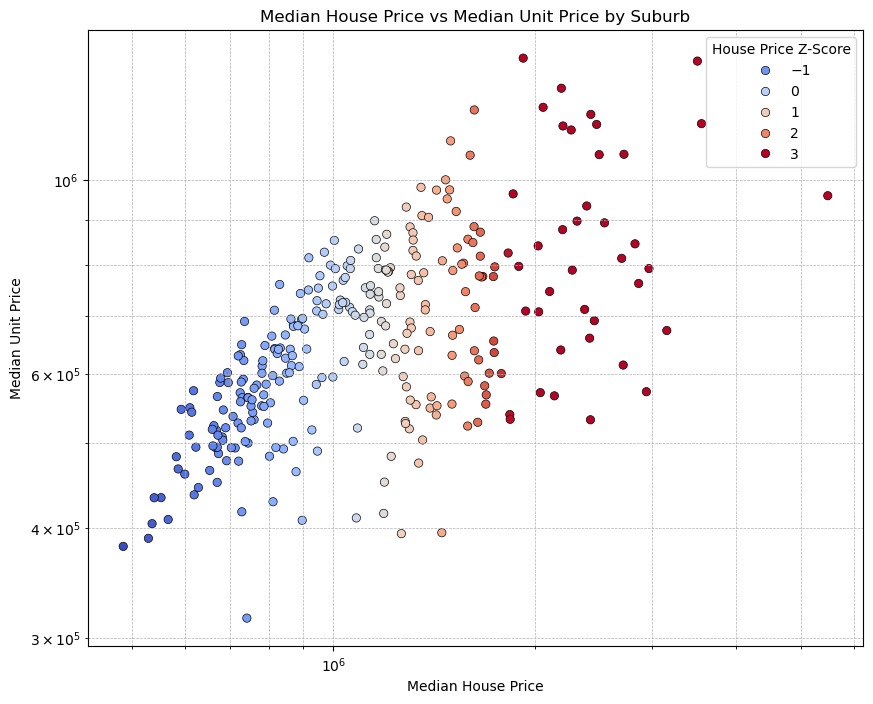

In [598]:
# Using matplotlib and seaborn to plot median House Price vs median Unit Price, with points with suburb name tooltip
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf_prices, x='medianHousePrice', y='medianUnitPrice', hue='housePriceScore', palette='coolwarm', edgecolor='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Median House Price')
plt.ylabel('Median Unit Price')
plt.title('Median House Price vs Median Unit Price by Suburb')
plt.legend(title='House Price Z-Score')
plt.grid(True, which="both", ls="--", linewidth=0.5)

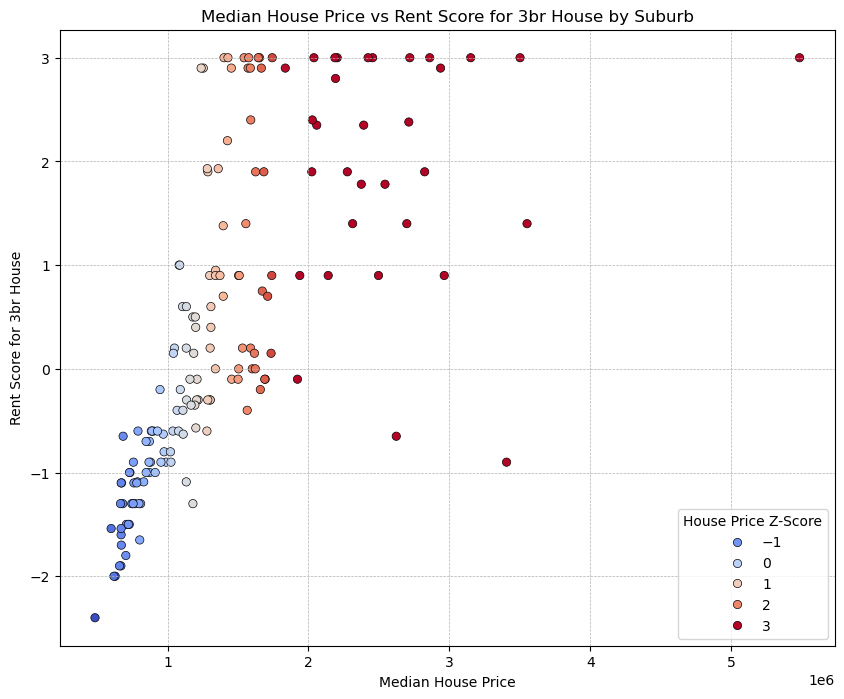

In [599]:
# Using matplotlib and seaborn to plot median House Price vs median Unit Price, with points with suburb name tooltip
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf_prices, x='medianHousePrice', y='rentScore_3brHouse', hue='housePriceScore', palette='coolwarm', edgecolor='k')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Median House Price')
plt.ylabel('Rent Score for 3br House')
plt.title('Median House Price vs Rent Score for 3br House by Suburb')
plt.legend(title='House Price Z-Score')
plt.grid(True, which="both", ls="--", linewidth=0.5)

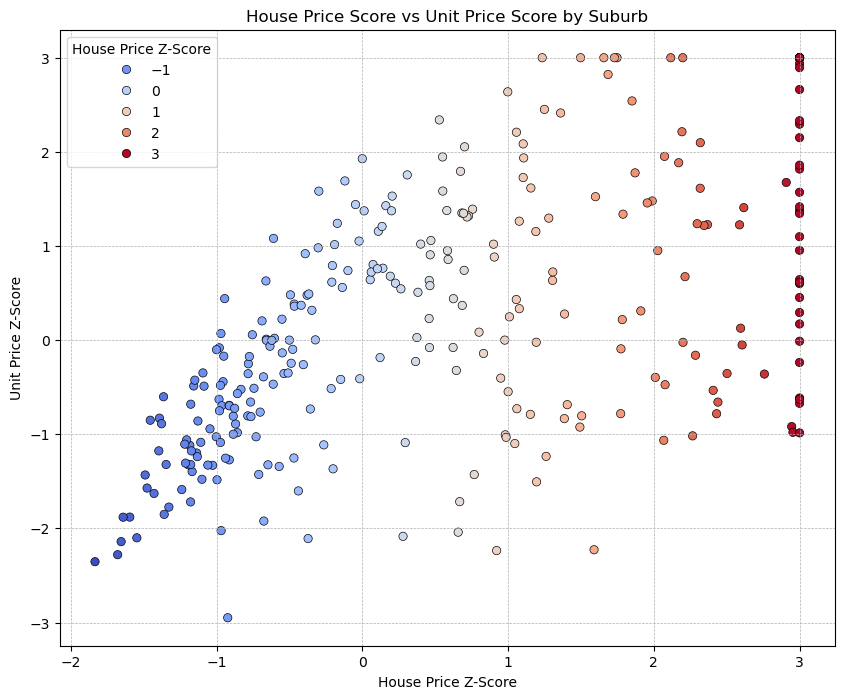

In [600]:
# Using matplotlib and seaborn to plot median House Price vs median Unit Price, with points with suburb name tooltip
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf_prices, x='housePriceScore', y='unitPriceScore', hue='housePriceScore', palette='coolwarm', edgecolor='k')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('House Price Z-Score')
plt.ylabel('Unit Price Z-Score')
plt.title('House Price Score vs Unit Price Score by Suburb')
plt.legend(title='House Price Z-Score')
plt.grid(True, which="both", ls="--", linewidth=0.5)

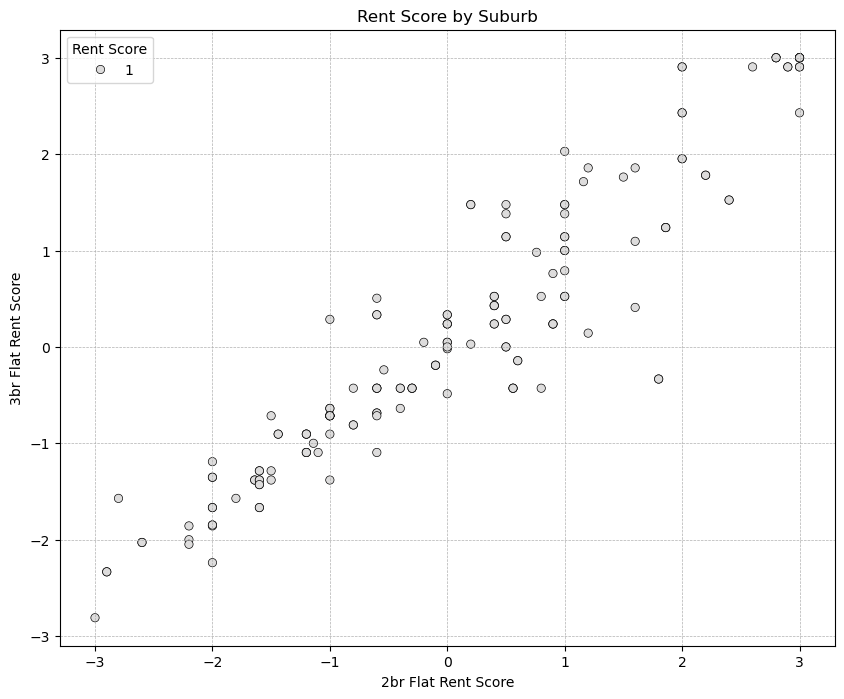

In [601]:
# Using matplotlib and seaborn to plot median House Price vs median Unit Price, with points with suburb name tooltip
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf_prices, x='rentScore_2brFlat', y='rentScore_3brFlat', hue=1, palette='coolwarm', edgecolor='k')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('2br Flat Rent Score')
plt.ylabel('3br Flat Rent Score')
plt.title('Rent Score by Suburb')
plt.legend(title='Rent Score')
plt.grid(True, which="both", ls="--", linewidth=0.5)

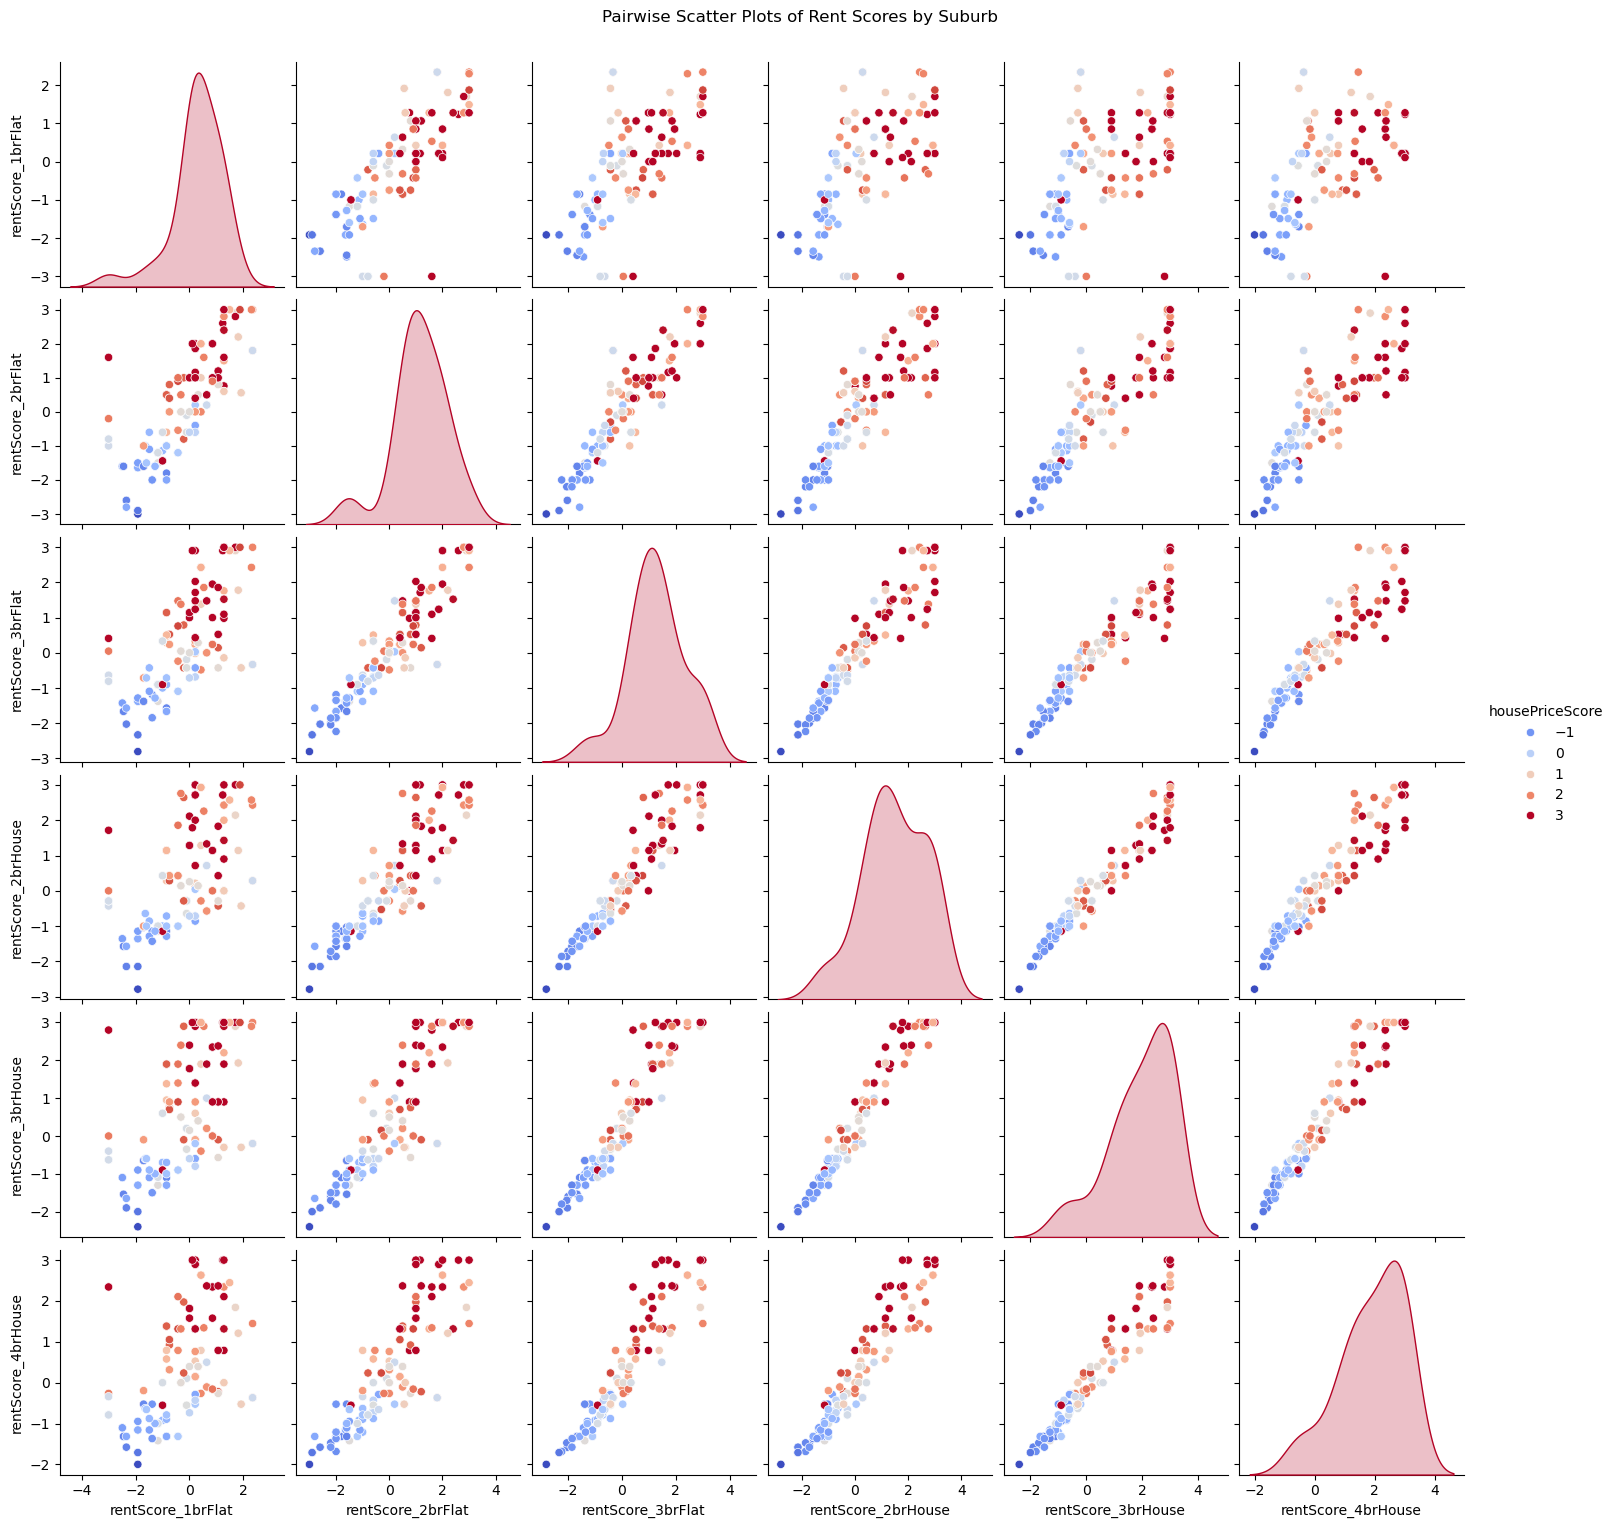

In [602]:
# create a matrix of scatter plots for all combinations of rent scores for flats and houses
rent_score_cols = ['rentScore_1brFlat', 'rentScore_2brFlat', 'rentScore_3brFlat', 'rentScore_2brHouse', 'rentScore_3brHouse', 'rentScore_4brHouse']
sns.pairplot(gdf_prices, vars=rent_score_cols, hue='housePriceScore', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairwise Scatter Plots of Rent Scores by Suburb', y=1.02)
plt.show()  